# PEA-STA Analysis

In [87]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt

DATA = 'PEA_STA'
embedding_dir = f'./embeddings/hgnn/PEA_STA-bce/'

In [88]:
cell_embeddings = np.load(f'{embedding_dir}/mymodel_0.npy')
gene_embeddings = np.load(f'{embedding_dir}/mymodel_1.npy')
omics_embeddings = np.load(f'{embedding_dir}/mymodel_2.npy')

node_names = pd.read_csv(f'./data/{DATA}/nodes.csv')["Name"]
metadata = json.load(open(f'./data/{DATA}/metadata.json'))

In [89]:
cell_names = node_names[metadata['cell_offset']:].values
cell_names

array(['u3035_6d_contol_A02', 'u3035_6d_contol_A03',
       'u3035_6d_contol_A04', 'u3035_6d_contol_A05',
       'u3035_6d_contol_A06', 'u3035_6d_contol_A07',
       'u3035_6d_contol_A08', 'u3035_6d_contol_A09',
       'u3035_6d_contol_A10', 'u3035_6d_contol_A11',
       'u3035_6d_contol_A12', 'u3035_6d_contol_B02',
       'u3035_6d_contol_B03', 'u3035_6d_contol_B04',
       'u3035_6d_contol_B05', 'u3035_6d_contol_B06',
       'u3035_6d_contol_B07', 'u3035_6d_contol_B08',
       'u3035_6d_contol_B09', 'u3035_6d_contol_B10',
       'u3035_6d_contol_B11', 'u3035_6d_contol_B12',
       'u3035_6d_contol_C01', 'u3035_6d_contol_C02',
       'u3035_6d_contol_C03', 'u3035_6d_contol_C04',
       'u3035_6d_contol_C05', 'u3035_6d_contol_C08',
       'u3035_6d_contol_C09', 'u3035_6d_contol_C10',
       'u3035_6d_contol_C11', 'u3035_6d_contol_C12',
       'u3035_6d_contol_D01', 'u3035_6d_contol_D02',
       'u3035_6d_contol_D03', 'u3035_6d_contol_D04',
       'u3035_6d_contol_D12', 'u3035_6d_contol

In [90]:
def find_cell_stage(cell_id):
    if '0h' in cell_id:
        return '0h untreated'
    if '6d' in cell_id:
        if 'contol' in cell_id:
            return '6d untreated'
        if 'BMP4' in cell_id:
            return '6d BMP4 treated'
    raise ValueError(cell_id)

cell_stage_from_id = [find_cell_stage(x) for x in cell_names]

In [91]:
# Check the stage and name.
assert len(cell_stage_from_id) == len(cell_names)

In [92]:
gene_names = node_names[metadata['gene_offset']: metadata['gene_offset'] + metadata['num_genes']].values
len(gene_names)

166

## A. Cell Embeddings UMAP

Text(0, 0.5, 'UMAP_2')

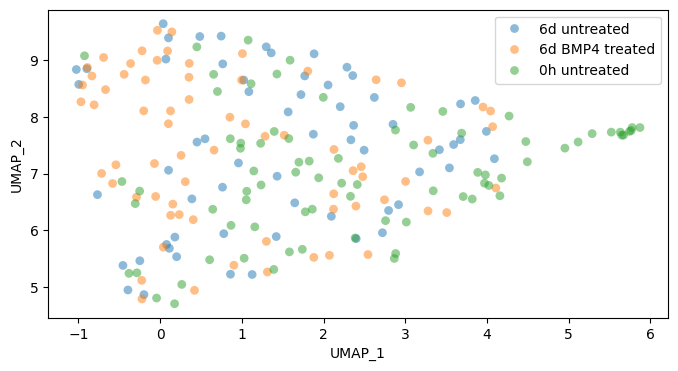

In [93]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id,
                s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


In [94]:
EXPR_LIST = [
    "1D1", "1D2", "SNAL1", "TUBB3"
]
import re
GENE_RE = re.compile('|'.join(EXPR_LIST))

In [95]:
gene_list = [
    "CAV1", "SOD1", "GFAP", "CASP8", "IKBKG", "VIM", "SMAD4", "CDKN1B",
    "PXN", "MIF", "SOD2", "ID1", "SOX2", "MELK", "PLAU", "XIAP", "PLCG1",
    "EGF", "TGFB1", "EGFR", "CDKN2C", "MKI67", "NPM1", "ERBB2", "EPHA2"
]


In [96]:
df_gene = pd.DataFrame(gene_embeddings.T, columns=gene_names)
df_gene

,AKT1_expr,AXIN2_expr,BAX_expr,BCL2_expr,BCL2L1_expr,BMI1_expr,BMP2_expr,BMP4_expr,BMPR1A_expr,BMPR1B_expr,...,SOX9_protein,TENASCIN.C_protein,TGFB1_protein,THY1_protein,TNFRSF10B_protein,TNFRSF1A_protein,TP53_protein,VEGFA_protein,VIM_protein,XIAP_protein
0,-0.038888,0.182354,0.234966,-0.098842,0.190549,0.095321,0.014260,0.155438,0.046930,0.180372,...,0.100842,0.081187,-0.028759,0.187729,0.052628,0.015443,0.127643,0.104680,0.120065,0.262026
1,0.124866,-0.136023,-0.110517,0.099425,-0.175140,-0.140065,-0.040268,-0.101714,-0.034505,-0.085580,...,0.029734,-0.102027,0.047267,-0.169542,0.003309,0.017398,-0.194885,0.111222,-0.076551,0.045827
2,0.261244,0.156358,0.078040,0.235063,0.116102,0.117972,0.104966,0.101500,0.131265,0.022969,...,0.178165,0.068116,0.095249,0.259464,0.034069,0.140679,0.116951,0.018828,0.105988,0.047752
3,0.214085,0.156123,0.080912,0.299914,0.182972,0.199733,0.351286,0.261326,0.199635,0.142318,...,0.185877,0.234977,0.283154,0.329331,0.164831,0.274159,0.118027,0.205778,0.176641,0.073271
4,0.234958,0.180967,0.240040,0.192512,0.202080,0.256260,0.147271,0.136292,0.179079,0.183295,...,0.169107,-0.018602,0.096528,0.087726,0.141435,0.101645,-0.063394,0.151204,0.032878,0.188923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,-0.146006,-0.069625,-0.028834,-0.174706,0.076006,-0.064203,-0.120496,-0.018572,-0.062106,-0.062735,...,-0.140551,-0.081919,-0.137647,-0.202262,-0.203215,-0.102029,-0.090061,-0.212394,-0.113040,-0.253346
60,0.074166,-0.399872,-0.429425,0.036331,-0.205310,-0.207519,-0.127274,-0.301050,-0.144846,-0.336235,...,-0.029649,-0.216687,-0.130713,-0.087491,-0.070722,-0.035900,-0.053346,-0.125745,-0.212252,-0.071814
61,-0.186694,-0.073002,-0.139243,-0.166603,-0.190154,-0.138702,-0.226310,-0.150032,-0.056217,-0.170705,...,-0.170215,0.017611,-0.159894,-0.198592,-0.079412,-0.101311,0.057308,-0.099238,-0.130471,-0.023869
62,0.162580,-0.149730,-0.061250,0.171580,0.074622,-0.045147,-0.048542,0.041907,0.026181,0.006690,...,0.010250,-0.150984,-0.020246,-0.019547,-0.051507,-0.059177,-0.182236,-0.001885,-0.016603,-0.169371


## C. Protein and RNA correlations

In [97]:
omics_embeddings[0, :].shape

(64,)

In [98]:
df_expr = df_gene.loc[:, df_gene.columns.str.endswith('_expr')].rename(lambda x: x.replace('_expr', ''), axis=1)
df_expr = df_expr.loc[:, gene_list] + omics_embeddings[0, :].reshape((-1, 1))

In [99]:
df_protein = df_gene.loc[:, df_gene.columns.str.endswith('_protein')].rename(lambda x: x.replace('_protein', ''), axis=1)
df_protein = df_protein.loc[:, gene_list] + omics_embeddings[1, :].reshape((-1, 1))

In [100]:
df_corr = df_expr.corrwith(df_protein, method='pearson')

Text(0.5, 0, 'Pearson correlation coefficients')

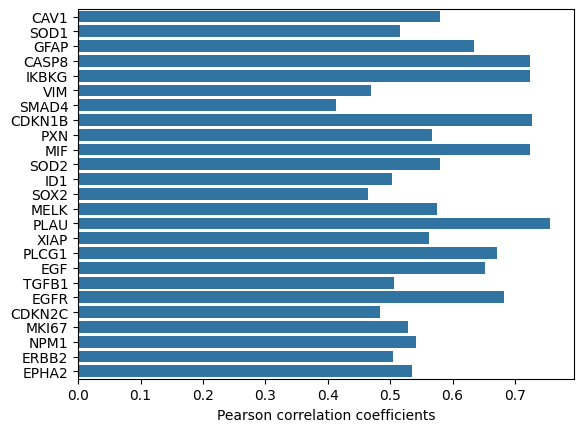

In [101]:
sns.barplot(df_corr, orient='h')
plt.xlabel('Pearson correlation coefficients')

In [102]:
df_cell = pd.DataFrame(cell_embeddings, index=cell_names)


Text(0.5, 1.0, 'CAV1')

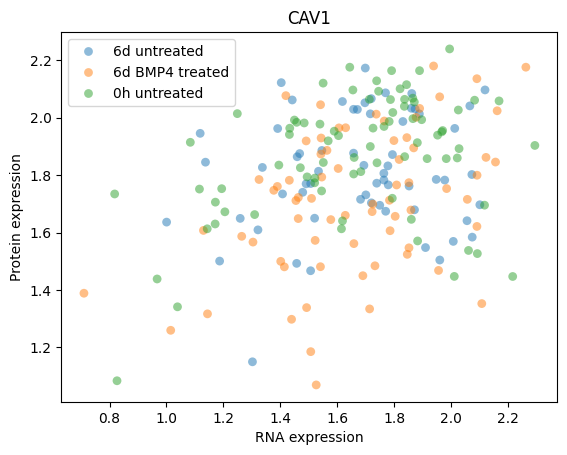

In [103]:
GENE = 'CAV1'
sns.scatterplot(x=df_cell @ df_expr[GENE].T, y=df_cell @ df_protein[GENE].T,
                hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.xlabel('RNA expression')
plt.ylabel('Protein expression')
plt.title(GENE)

Text(0.5, 1.0, 'SOD1')

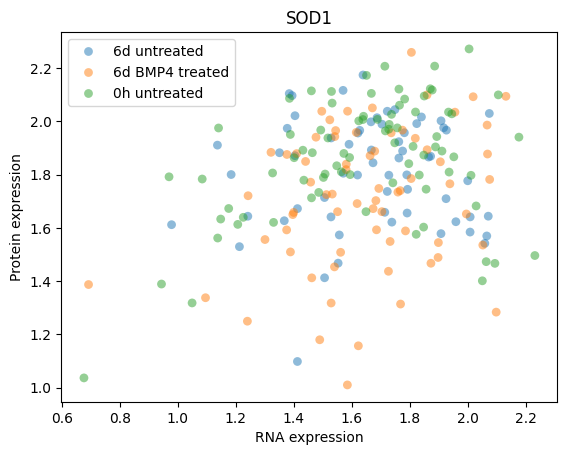

In [104]:
GENE = 'SOD1'
sns.scatterplot(x=df_cell @ df_expr[GENE].T, y=df_cell @ df_protein[GENE].T,
                hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.xlabel('RNA expression')
plt.ylabel('Protein expression')
plt.title(GENE)

Text(0.5, 1.0, 'ERBB2')

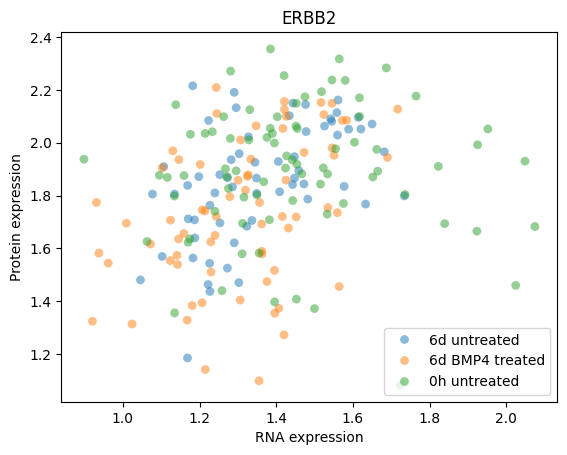

In [105]:
GENE = 'ERBB2'
sns.scatterplot(x=df_cell @ df_expr[GENE].T, y=df_cell @ df_protein[GENE].T,
                hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.xlabel('RNA expression')
plt.ylabel('Protein expression')
plt.title(GENE)

Text(0.5, 1.0, 'EPHA2')

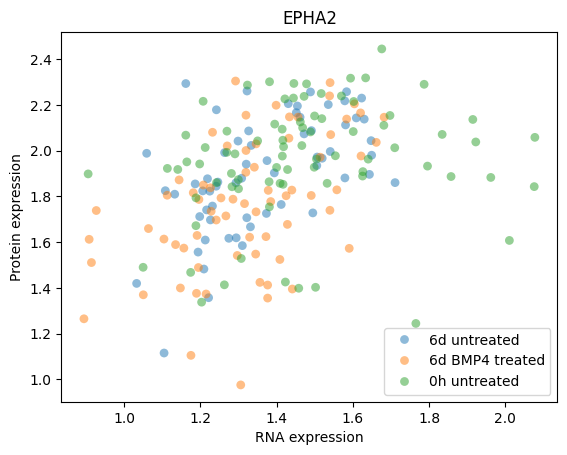

In [106]:
GENE = 'EPHA2'
sns.scatterplot(x=df_cell @ df_expr[GENE].T, y=df_cell @ df_protein[GENE].T,
                hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.xlabel('RNA expression')
plt.ylabel('Protein expression')
plt.title(GENE)

## D. Gene embeddings on cells

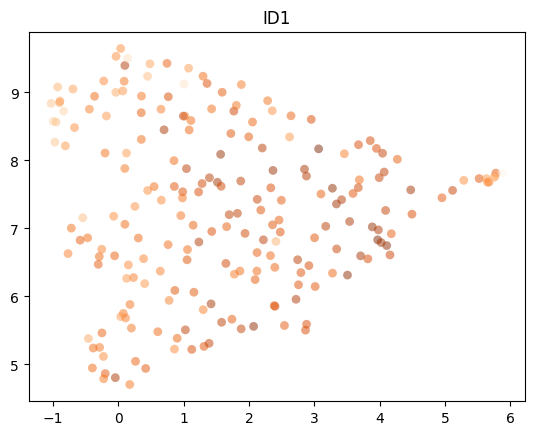

In [107]:
ID1_proj = df_cell @ df_protein['ID1'] + df_cell @ df_expr['ID1']

sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=ID1_proj,
                s=S, linewidth=0, alpha=0.5, palette='Oranges')
plt.xlabel("")
plt.ylabel("")
plt.title("ID1")
plt.legend().remove()

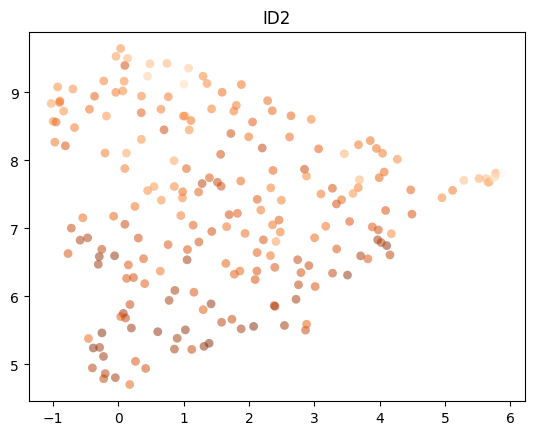

In [108]:
ID2_proj = df_cell @ df_gene['ID2_expr']

sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=ID2_proj,
                s=S, linewidth=0, alpha=0.5, palette='Oranges')
plt.xlabel("")
plt.ylabel("")
plt.title("ID2")
plt.legend().remove()

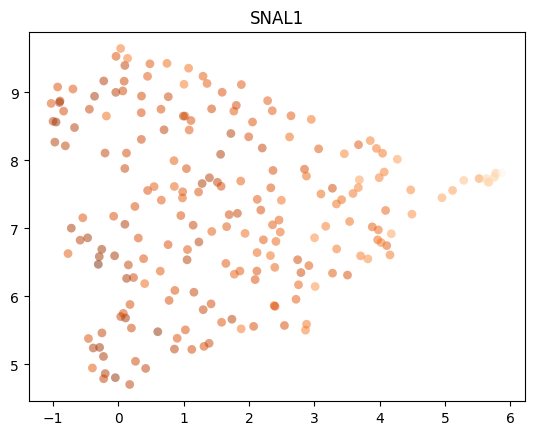

In [109]:
ID1_proj = df_cell @ df_gene['SNAL1_expr']

sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=ID1_proj,
                s=S, linewidth=0, alpha=0.5, palette='Oranges')
plt.xlabel("")
plt.ylabel("")
plt.title("SNAL1")
plt.legend().remove()

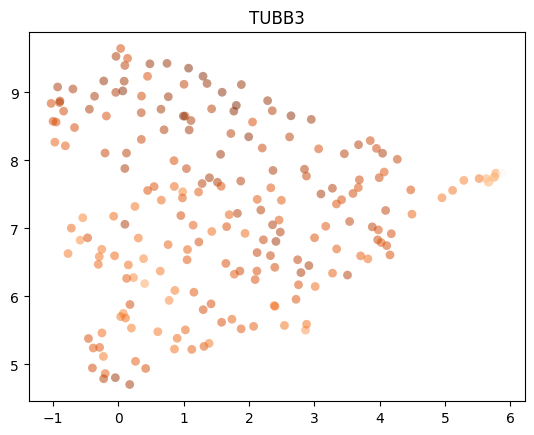

In [110]:
ID1_proj = df_cell @ df_gene['TUBB3_expr']

sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=ID1_proj,
                s=S, linewidth=0, alpha=0.5, palette='Oranges')
plt.xlabel("")
plt.ylabel("")
plt.title("TUBB3")
plt.legend().remove()

## Cell Clustering

In [111]:
from sklearn.cluster import k_means

cell_stage = set(cell_stage_from_id)

_, cluster, _ = k_means(UMAP(3).fit_transform(cell_embeddings), n_clusters=len(cell_stage))
cluster.shape

(210,)

In [112]:
cell_stage_ids = {lbl : i for i, lbl in enumerate(cell_stage)}
cell_stage_ids

{'0h untreated': 0, '6d BMP4 treated': 1, '6d untreated': 2}

In [113]:
cell_stage_label = [cell_stage_ids[y] for y in cell_stage_from_id]

In [114]:
from scipy.optimize import linear_sum_assignment

def align_cluster(cluster_ids, y):
    kc = len(np.unique(cluster_ids))
    ky = len(np.unique(y))
    # ---------- 3. build cost matrix ----------
    contingency = np.zeros((kc, ky), dtype=int)
    for c, gt in zip(cluster_ids, y):
        contingency[c, gt] += 1

    # cost = number of mismatches if we map cluster c -> class j
    cost_matrix = contingency.max() - contingency        # or: -contingency

    # ---------- 4. Hungarian ----------
    row_ind, col_ind = linear_sum_assignment(cost_matrix)   # same API as old linear_assignment

    # ---------- 5. remap ----------
    # build a dictionary  old_label -> new_label
    mapping = dict(zip(row_ind, col_ind))
    y_pred_aligned = np.vectorize(mapping.get)(cluster_ids)
    return y_pred_aligned


In [115]:
from sklearn.metrics import normalized_mutual_info_score # NMI
from sklearn.metrics import adjusted_rand_score # ARI
from sklearn.metrics import fowlkes_mallows_score # FMI

In [116]:
def compute_clustering_metrics(y_true, y_pred_aligned):
    return dict(
        NMI = normalized_mutual_info_score(y_true, y_pred_aligned),
        ARI = adjusted_rand_score(y_true, y_pred_aligned),
        FMI = fowlkes_mallows_score(y_true, y_pred_aligned),
    )

In [117]:
y_pred_aligned = align_cluster(cluster, cell_stage_label)

In [118]:
metrics = compute_clustering_metrics(cell_stage_label, y_pred_aligned)
metrics


{'NMI': 0.06053412638288114,
 'ARI': 0.06223855050236458,
 'FMI': 0.3811857688364388}

### Baselines

t-SNE, PCA, UMAP.

In [119]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

from scoit.cell_analysis import RunLeiden, RunLouvain, knn_adj_matrix

In [120]:
from hgnn.hypergraph import HyperGraphCreator
from pathlib import Path

create = HyperGraphCreator({
        'expr': './data/PEA_STA/expression_data.csv',
        'protein': './data/PEA_STA/protein_data.csv',
    }, cell_key='Cells ', dataname='PEA_STA', prefix=Path('./data'))

In [121]:
create.load_and_preprocess_data()

Begin to load multi omics data {'expr': './data/PEA_STA/expression_data.csv', 'protein': './data/PEA_STA/protein_data.csv'}
Load data done, time: 0.012645244598388672
Rename columns
Name: expr, Columns: Index(['AKT1_expr', 'APC_expr', 'APP_expr', 'AURKB_expr', 'AXIN1_expr',
       'AXIN2_expr', 'BAX_expr', 'BCL2_expr', 'BCL2L1_expr', 'BCL6_expr',
       ...
       'THY1_expr', 'TNFRSF10B_expr', 'TNFRSF1A_expr', 'TP53_expr',
       'TRADD_expr', 'TUBB3_expr', 'TWSG1_expr', 'VEGFA_expr', 'VIM_expr',
       'XIAP_expr'],
      dtype='object', length=141)
Name: protein, Columns: Index(['AKT1_protein', 'APC_protein', 'APP_protein', 'AURKB_protein',
       'AXIN1_protein', 'AXIN2_protein', 'BAX_protein', 'BCL2_protein',
       'BCL2L1_protein', 'BCL6_protein',
       ...
       'THY1_protein', 'TNFRSF10B_protein', 'TNFRSF1A_protein', 'TP53_protein',
       'TRADD_protein', 'TUBB3_protein', 'TWSG1_protein', 'VEGFA_protein',
       'VIM_protein', 'XIAP_protein'],
      dtype='object', length=1

In [122]:
assert (create.df.index == cell_names).all().all()


In [123]:
features = create.df.values
features.shape

(210, 166)

In [124]:
baselines = {
    'TSNE' : TSNE,
    'PCA': PCA,
    'UMAP': UMAP,
    'Ours': None, # Placeholder
}

def run_baselines(features, cell_embeddings, dims=3):
    records = []
    k = len(np.unique(cell_stage_label))

    for name, method in baselines.items():
        print(name)
        if method is None:
            x = cell_embeddings
        else:
            x = method(n_components=dims).fit_transform(features)

        x_norm = np.linalg.norm(x, axis=1).reshape((-1, 1))
        x = x / x_norm
        _, c, _ = k_means(x, k)
        c_aligned = align_cluster(c, cell_stage_label)
        kmeans_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in kmeans_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='kmeans'))

        # adj = knn_adj_matrix(x, 10)
        # c = RunLeiden(adj)
        # c_aligned = align_cluster(c, cell_stage_label)
        # leiden_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        # for key, value in leiden_metrics.items():
        #     records.append(dict(method=name, metric=key, value=value, task='leiden'))

    return pd.DataFrame.from_records(records)


Text(0, 0.5, 'UMAP_2')

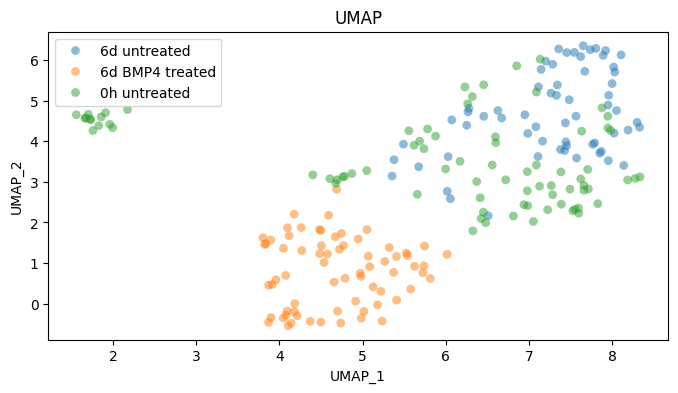

In [125]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(features)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('UMAP')
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


Text(0, 0.5, 'TSNE_2')

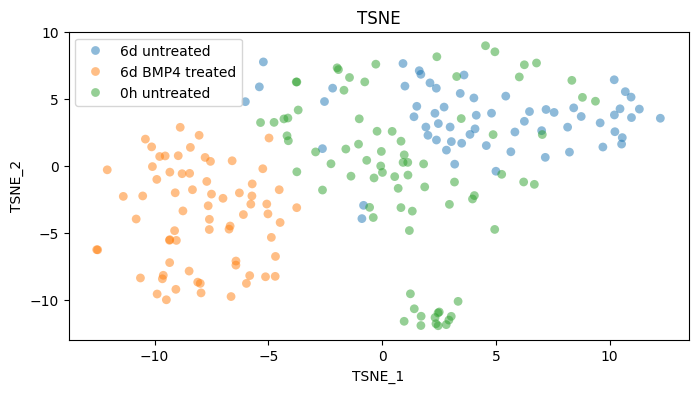

In [126]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = TSNE(n_components=2).fit_transform(features)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('TSNE')
plt.xlabel("TSNE_1")
plt.ylabel("TSNE_2")


### K-means performance

In [127]:
df_cluster = run_baselines(features, cell_embeddings)

TSNE
PCA
UMAP
Ours


Text(0, 0.5, '')

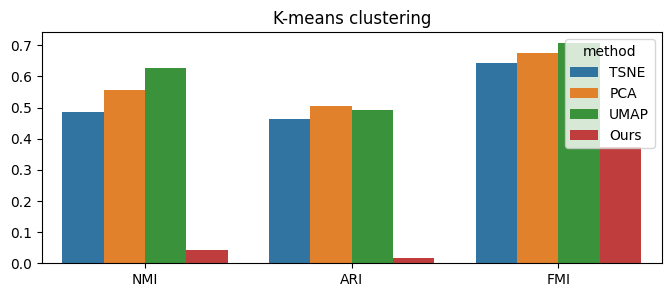

In [128]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'kmeans'], x='metric', y='value', hue='method')
plt.title('K-means clustering')
plt.xlabel('')
plt.ylabel('')

### Leiden community detection

Text(0, 0.5, '')

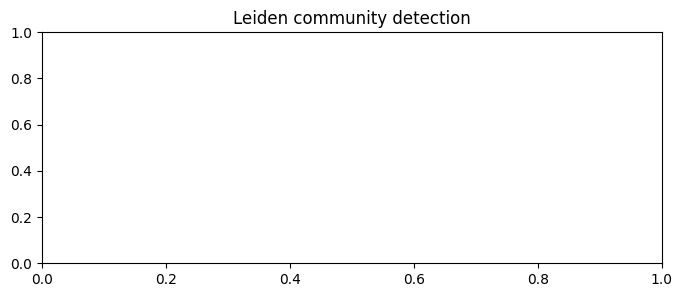

In [129]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'leiden'], x='metric', y='value', hue='method')
plt.title('Leiden community detection')
plt.xlabel('')
plt.ylabel('')